<a href="https://colab.research.google.com/github/headhuncho1234/HW/blob/main/CIS8694_Fall2025_Assignment4MM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Assignment 4: Sentiment analysis with machine learning



This assignment has **four parts:**
1. Data Collection - Make your own review.csv
2. Classifying overall scores for Amazon products using open-source libraries
3. Classifying overall scores for Amazon products using Monkeylearn
4. Get some insights



**The assignment folder** has a number of files and folders. They relate to the parts of the assignment as follows:
This notebook (which you've apparently already found)

* train.json - training data for reviews of Amazon products
* test.json - test data for reviews of Amazon products
* review.csv - a template of test data for reviews of the products from your firm





## Part 1: Data Collection
---


**<font color="blue">q1.</font>We are going to collect the top 20 most recent reviews from Amazon. Please specify your product name, url to this product at Amazon.com. Then save the top 20 most recent reviews to the csv file review.csv**

In [1]:
print (len(("Describe your product name").split()) < 14)
print (len(("copy url here")))

True
13




## Part 2: Classifying overall scores for Amazon products using open-source libraries
---

In this part of the assignment you'll use text from a large set of reviews of products on amazon.com to train a machine learning model to predict what overall score the reviewer gave the product. The public dataset is from [here](http://jmcauley.ucsd.edu/data/amazon/).  

There are 198502 reviews total across the training and test dataset, and we've kind of arbitrarily separated them into 90% for training, and 10% for testing... ish. The exact percentages don't matter too much here.

Take a look at what's inside the data. You can open it in a browser or a text editor. Both should show you tons of text. If you haven't seen .json data before, this is what it looks like. Each review object starts with a { and ends with a }, and contains a bunch of features separated by commas. Each feature has a name and a value.

**<font color="blue">q2.</font>In 13 words or less per feature, explain what you think each feature in the dataset means in the box below.**

In [2]:
print (len(("[Feature 1 name] means ... Your explanation ").split()) < 14)
print (len(("[Feature 2 name] means ... Your explanation ").split()) < 14)
print (len(("[Feature 3 name] means ... Your explanation ").split()) < 14)
# Keep going until you have all the features

True
True
True






### 2.1 Importing the public amazon review data






The first thing we have to do is import the data. Normally json data is really easy to import, but this file is in a slightly annoying format. Notably, the reviews don't have commas separating them. Fortunately this is pretty easy to overcome with a bit of iterating. For this assignment, we only care about the review text and the overall score within each review. To save you a bit of googling, you can access individual items within a json object by doing object["featurename"].

**<font color="blue">q3</font>. Importing amazon review data into X and y arrays for train and test sets. Please complete the missing code segement**

In [5]:

# Read train.json, put your resulting data in series named:
# "Train_X", "Train_y"
# with X as review text and y as overall score

import json
import pandas as pd

with open('train.json') as f:
    lines = f.read().splitlines()

df = pd.DataFrame(lines)
df.columns=['json_element']

df_new=pd.json_normalize(df['json_element'].apply(json.loads))

Train_X = df_new['reviewText']
Train_y = df_new['overall']



JSONDecodeError: Expecting ',' delimiter: line 1 column 1633 (char 1632)

In [ ]:
# Read test.json, put your resulting data in series named:
# "Test_X", and "Test_y"
# with X as review text and y as overall score

# Put your code here.......

In [ ]:
# If you've done this right, you should get (188502,) (188502,) (10000,) (10000,)
print (Train_X.shape, Train_y.shape, Test_X.shape, Test_y.shape)

Let us look at the first 5 reviews from Training data and Test data seperately. Feel free to add code by yourself to check corresponding review scores.

In [ ]:
Train_X[0:5]

In [ ]:
Test_X[0:5]

**<font color="blue">q4.</font> Let us convert review scores from numbers to texts. Positive reviews have ratings equal to 5 or 4; Neutral reviews are with ratings equal to 3; Negative reviews have ratings equal to 2 or 1.**


In [ ]:
def sentiments(rating):
    if (rating == 5) or (rating == 4):
        return "Positive"
    elif rating == 3:
        return "Neutral"
    # Add your code here for converting ratings of nagative reviews.....



# Add sentiments to the data
Train_y = Train_y.apply(sentiments)
Test_y = Test_y.apply(sentiments)

Display the sentiments of first 5 reviews from traning data.


In [ ]:
Train_y[:5]

###2.2 : Extract features

Here we will turn content into numerical feature vectors using the **Bag of Words** strategy:

>  *   Assign fixed integer id to each word occurrence (integer indices to word occurrence dictionary)
>  *  X[i,j] where i is the integer indices, j is the word occurrence, and X is an array of words (our training set)

In order to implement the **[Bag of Words](https://en.wikipedia.org/wiki/Bag-of-words_model)** strategy, we will use SciKit-Learn’s **[CountVectorizer](https://www.educative.io/edpresso/countvectorizer-in-python)** to performs the following:

Text preprocessing:
*   Tokenization (breaking sentences into words)
*   Stopwords (filtering “the”, “are”, etc)
*   Occurrence counting (builds a dictionary of features from integer indices with word occurrences)
*   Feature Vector (converts the dictionary of text documents into a feature vector)





In [ ]:
# Text preprocessing and occurance counting
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
Train_X_counts = count_vect.fit_transform(Train_X)
Train_X_counts.shape

Here we have 188502 reviews ans 75775 distinct words in our training sample.

**<font color="blue">q5.</font> Please explain what does Train_X_counts[0].toarray() represent?**

In [ ]:
Train_X_counts[0].toarray()


In [ ]:
print (len(("put your answer here")))


Also, with longer documents, we typically see higher average count values on words that carry very little meaning, this will overshadow shorter documents that have lower average counts with same frequencies, as a result, we will use **TfidfTransformer** to reduce this redundancy:
*  Term Frequencies (Tf) divides number of occurrences for each word by total number of words
*  Term Frequencies times Inverse Document Frequency (Tfidf) downscales the weights of each word (assigns less value to unimportant stop words ie. “the”, “are”, etc)


In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf_transformer = TfidfTransformer(use_idf=False)
Train_X_tfidf = tfidf_transformer.fit_transform(Train_X_counts)


**<font color="blue">q6.</font>Display the shape of Train_X_tfidf. Please explain why the shape of Train_X_tfidf is the same as Train_X_counts?**

In [ ]:
#Put your code here to display the shape of Train_X_tfidf....



In [ ]:
print (len(("put your answer here")))


###2.3 Build your model



Frist, we will use Multinominal Naive Bayes as our Classifier

*  Multinominal Niave Bayes is most suitable for word counts where data are typically represented as word vector counts (number of times outcome number X[i,j] is observed over the n trials), while also ignoring non-occurrences of a feature i
*  Naive Bayes is a simplified version of Bayes Theorem, where all features are assumed conditioned independent to each other (the classifiers), P(x|y) where x is the feature and y is the classifier

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
clf_multiNB_pipe = Pipeline([("vect", CountVectorizer()),
                             ("tfidf", TfidfTransformer()),
                             ("clf_nominalNB", MultinomialNB())])
clf_multiNB_pipe.fit(Train_X, Train_y)

###2.4 Test model

In [ ]:
import numpy as np
predictedMultiNB = clf_multiNB_pipe.predict(Test_X)
np.mean(predictedMultiNB == Test_y)

**<font color="blue">q7.</font> Please explain what measure is calculated in above code for checking the prediction performance?**

In [ ]:
print (len(("put your answer here")))

Test review.csv, display the mean again as in previous example.

In [ ]:
pd_review = pd.read_csv('review.csv')

# Add sentiments to the data
review_X = pd_review['reviewText']
review_y = pd_review['overall'].apply(sentiments)

predictedMultiNB = clf_multiNB_pipe.predict(review_X)
np.mean(predictedMultiNB == review_y)

**<font color="blue">q8.</font> Display the predicted sentiment for the reviews from 'review.csv'.**

In [ ]:
# Put your code here.....


###2.5 Testing other models

Logistic Regression Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
clf_logReg_pipe = # put your code here.....

clf_logReg_pipe.fit(Train_X, Train_y)

import numpy as np
# put your code here.....


np.mean(predictedLogReg == Test_y)



```
# This is formatted as code
```

Support Vector Machine Classifier

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
clf_linearSVC_pipe = Pipeline([("vect", CountVectorizer()),
                             ("tfidf", TfidfTransformer()),
                             ("clf_nominalNB", LinearSVC())])
clf_linearSVC_pipe.fit(Train_X, Train_y)

import numpy as np
predictedLinearSVC = clf_linearSVC_pipe.predict(Test_X)
np.mean(predictedLinearSVC == Test_y)

###2.6 Fine tuning the Support Vector Machine Classifier

*  Here we will run a Grid Search of the best parameters on a grid of possible values, instead of tweaking the parameters of various components of the chain (ie. use_idf in tfidftransformer)
*  We will also run the grid search with LinearSVC classifier pipeline, parameters and cpu core maximization
*  Then we will fit the grid search to our training data set


Finally we will test the accuracy of our final classifier (after fine-tuning).

Note: this step may take a long time. Please be patient.

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters = {'vect__ngram_range': [(1, 1), (1, 2)],
             'tfidf__use_idf': (True, False),
             }
gs_clf_LinearSVC_pipe = GridSearchCV(clf_linearSVC_pipe, parameters, n_jobs=-1)
gs_clf_LinearSVC_pipe = gs_clf_LinearSVC_pipe.fit(Train_X,
                                                  Train_y)


predictedGS_clf_LinearSVC_pipe = gs_clf_LinearSVC_pipe.predict(Test_X)
np.mean(predictedGS_clf_LinearSVC_pipe == Test_y)

## Part 3: Classifying overall scores for Amazon products using text2data
-----

**text2data** is an easy-to-use text analysis cloud platform that hosts an array of pre-trained models for tasks like sentiment analysis, document classification, detections of entities, themes, keywords and etc.

You can even build and train your own text analysis models in a few simple steps, and tailor them to your business needs, then connect them with APIs (available in all programming languages) to your favorite tools.

Once you’ve signed up to text2data, you’ll also have access to your own API key and secret that you can simply copy and paste into integrated tools, like Google Sheets, excel, and your own program.

text2data is not free. But you can sign up at [text2data](https://text2data.com/Account/Register) and get a free plan. The free plan allows you to upload at maximum 1000 reviews in the first month to the cloud for analysis.

Please watch out avaialbe remaining transactions and do not use out all of them before you submit your assignment.

###3.1 Sign in your text2data account. Locate and copy your API key and set your secret code at your profile

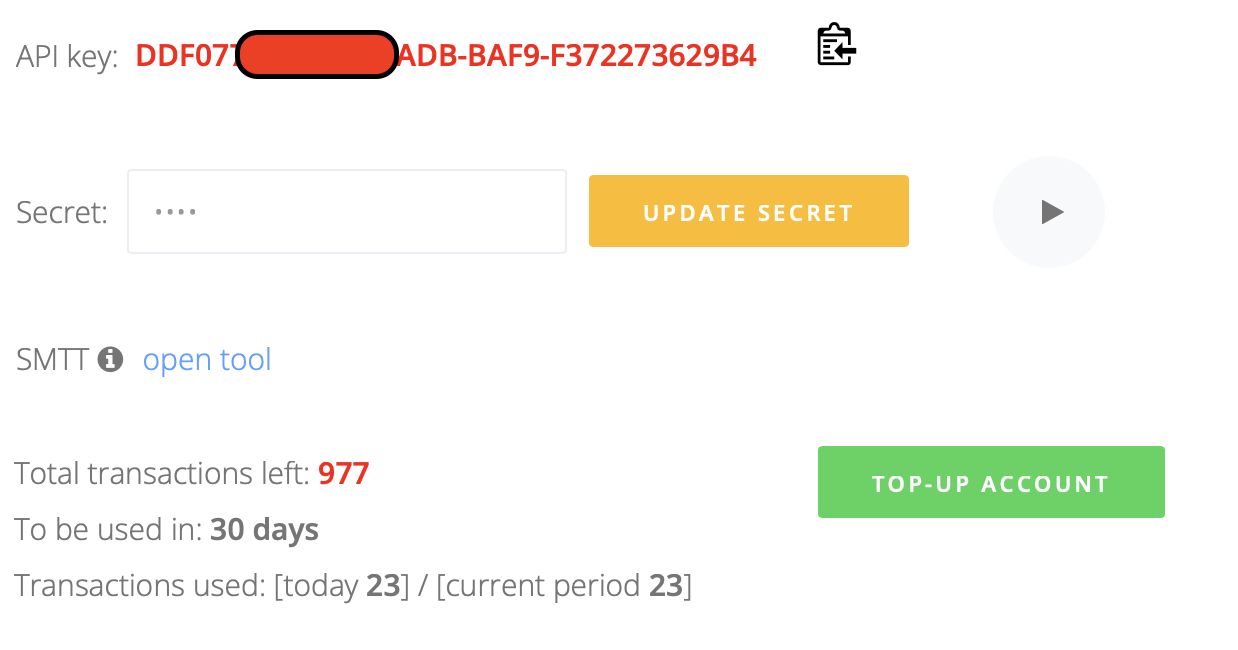

When you are tring to connect the text2data's cloud, API key and secret code is used for authentication.

###3.2 Use Text Analysis in Google Sheets

Open [this webpage](https://text2data.com/Google-Sheets), install add-on on your own google account and read the tutorial.
1. Open [google spreadsheet](https://docs.google.com/spreadsheets/).
2. Copy the reviews from review.csv to the google spreadsheet.
3. Open the add-on at google spreadsheet (Extensions -> Ⓣ Text Analytics and Sentiment Analysis ) and enter your credentials.
4. Then configure the add on by checking all services (Extensions -> Ⓣ Text Analytics and Sentiment Analysis -> service settings).
5. Select all the reviews and analyze it ( Extensions -> Ⓣ Text Analytics and Sentiment Analysis -> Analyze Selections [Sentiment Analysis]).

**<font color='blue'>q9.</font> How many of your reviews are classified as positive?**

In [ ]:
print (len(("put your answer here")))

##Part 4: Classifying overall scores for Amazon products using OpenAI API

[Create an API key in the dashboard here](https://platform.openai.com/api-keys), which you’ll use to securely access the API.  Install the OpenAI Library by running the following command and set up Your API Key.

In [ ]:
!pip install openai

In [ ]:
#Set Up Your API Key
import os
os.environ["OPENAI_API_KEY"] = "!!!!put your openai api key here!!!!"

You could now define your open API request via code below

In [ ]:
import openai

openai.api_key = os.getenv("OPENAI_API_KEY")

def request_openai(input):
  client = openai.OpenAI()


  response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
      {
        "role": "system",
        "content": [
          {
            "type": "text",
            "text": "You are a help assistant."
          }
        ]
      },
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": f"[Task] Classify Amazon reviews below into \"Positive\", \"Neutral\", or \"Negative\".\n[Input]\n{input}\n[Output]\nSentiment\n"
          }
        ]
      }

    ],
    temperature=1,
    max_tokens=2048,
    top_p=1,
    frequency_penalty=0,
    presence_penalty=0,
    response_format={
      "type": "text"
    }
  )

  return response.choices[0].message.content

Test it on a single review and check output.

In [ ]:
review="My daughter loves it."
request_openai(review)

Import the reviews from "review.csv" and check how GPT-4o-mini classifies them.

In [ ]:
import pandas as pd
df=pd.read_csv("review.csv")
df['reviewText'].apply(request_openai)


## Part 4: Get Some insights
---

Compare the prediction results on the reviews from review.csv from Part 2, Part 3 and Part 4. Then answer following questions.

**<font color='blue'>q10.</font> Which method predicts the sentiment more accurately, the one using open-source libraries ,text2data, or GPT-4o-mini?**

In [ ]:
print (len(("put your answer here")))

**<font color='blue'>q11.</font> Can we improve the prediction accuracy for the method with worse performance? If yes, how to improve?**

In [ ]:
print (len(("put your answer here")))

**<font color='blue'>q12.</font>Which one do you want to select as the final solution of your firm to analyze amazon reviews? Please also explain why?**

In [ ]:
print (len(("put your answer here")))